## Preprocesamiento, modelado, comparación estadística e interpretabilidad



In [1]:
%pip install -q kagglehub pyspark lime statsmodels pyarrow psutil

Note: you may need to restart the kernel to use updated packages.


In [2]:
import itertools
import platform
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import scipy.sparse as sp
from scipy import stats as sps
from IPython.display import display, Markdown

import sklearn
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, auc, confusion_matrix)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline as SkPipeline   # solo para VERIFICAR (validación final) que no se usa
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
try:
    from sklearn.ensemble import HistGradientBoostingClassifier
except ImportError:   # scikit-learn < 1.0
    from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
    from sklearn.ensemble import HistGradientBoostingClassifier
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
ALPHA = 0.05
# Regla literal del enunciado: default=0 agrupa todo lo que no es "Charged Off" -> no se llama "Fully Paid".
CLASS_LABELS = {0: "No Charged Off (0)", 1: "Charged Off (1)"}

# Artefactos compartidos entre scikit-learn y PySpark (partición, puntuaciones, tablas y figuras)
ARTIFACTS_DIR = Path("artifacts_modelado")
FIG_DIR = ARTIFACTS_DIR / "figuras"
LIME_DIR = ARTIFACTS_DIR / "lime"
for d in (ARTIFACTS_DIR, FIG_DIR, LIME_DIR):
    d.mkdir(parents=True, exist_ok=True)
SPLIT_PATH = ARTIFACTS_DIR / "split_assignment.parquet"

# Registro único de tiempos (entorno, etapa, modelo, segundos) -> tabla final comparable
TIEMPOS = []


def registrar_tiempo(entorno, etapa, segundos, modelo=None):
    TIEMPOS.append({"entorno": entorno, "etapa": etapa, "modelo": modelo, "segundos": float(segundos)})


def guardar_figura(nombre):
    ruta = FIG_DIR / f"{nombre}.png"
    plt.savefig(ruta, dpi=120, bbox_inches="tight")
    return ruta


print(f"Directorio de artefactos: {ARTIFACTS_DIR.resolve()}")

Directorio de artefactos: C:\Users\juand\OneDrive\Desktop\MachineLearning\jbook_ml202603\docs\artifacts_modelado


### Hardware de ejecución

Se detecta automáticamente el hardware **del equipo donde realmente se ejecuta el notebook** (sistema operativo,
Python, CPU físicas y lógicas, RAM total y disponible) y se guarda en `hardware.csv`. No hay valores fijos: si el
notebook se ejecuta en otro computador, el reporte cambia.

In [3]:
vm = psutil.virtual_memory()
hardware = {
    "fecha_ejecucion": datetime.now().isoformat(timespec="seconds"),
    "sistema_operativo": f"{platform.system()} {platform.release()}",
    "version_so": platform.version(),
    "arquitectura": platform.machine(),
    "procesador": platform.processor() or "no reportado por el SO",
    "python": platform.python_version(),
    "cpu_fisicas": psutil.cpu_count(logical=False),
    "cpu_logicas": psutil.cpu_count(logical=True),
    "ram_total_gb": round(vm.total / 1024 ** 3, 2),
    "ram_disponible_gb": round(vm.available / 1024 ** 3, 2),
    "scikit_learn": sklearn.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
}
try:
    import pyspark
    hardware["pyspark"] = pyspark.__version__
except ImportError:
    hardware["pyspark"] = "no instalado"

hardware_df = pd.DataFrame([hardware])
hardware_df.to_csv(ARTIFACTS_DIR / "hardware.csv", index=False)
display(hardware_df.T.rename(columns={0: "valor"}))
print(f"Guardado en {ARTIFACTS_DIR / 'hardware.csv'}")

,valor
fecha_ejecucion,2026-09-30T08:59:05
sistema_operativo,Windows 10
version_so,10.0.26100
arquitectura,AMD64
procesador,"AMD64 Family 25 Model 117 Stepping 2, Authenti..."
python,3.9.25
cpu_fisicas,6
cpu_logicas,12
ram_total_gb,7.27
ram_disponible_gb,0.95


Guardado en artifacts_modelado\hardware.csv


### Variables de entrada al modelado

Lista base tomada de los ejemplos del enunciado (9.10.4.2.2). Si en el EDA se eligió otra selección
(`seleccion_final` en `1_EDA_reorganizado.ipynb`), basta con reemplazar estas dos listas: el resto del notebook solo
depende de que existan `NUMERIC_FEATURES` y `CATEGORICAL_FEATURES`.

`emp_length` se usa en su versión numérica `emp_length_num` (`"< 1 year"` → 0.5, `"1 year"` → 1, ...,
`"10+ years"` → 10), con **la misma regla** que en el EDA y la misma regla replicada en PySpark (sin UDF de Python).

In [4]:
# Variables seleccionadas en el EDA (9.10.4.1.5): sin leakage, sin cardinalidad extrema,
# sin >70% de faltantes y sin redundancia entre sí.
NUMERIC_FEATURES = ["int_rate", "fico_range_low", "acc_open_past_24mths", "inq_last_6mths",
                    "bc_open_to_buy", "percent_bc_gt_75", "inq_last_12m", "all_util"]
CATEGORICAL_FEATURES = ["sub_grade", "verification_status"]

# Columnas que se leen del CSV original (los indicadores de faltante se derivan después de leer).
COLUMNAS_CSV = ["id", "loan_status"] + NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Numéricas ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categóricas ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")


Numéricas (8): ['int_rate', 'fico_range_low', 'acc_open_past_24mths', 'inq_last_6mths', 'bc_open_to_buy', 'percent_bc_gt_75', 'inq_last_12m', 'all_util']
Categóricas (2): ['sub_grade', 'verification_status']


### Carga del dataset, identificador y variable objetivo (9.10.3)


In [5]:
import kagglehub

DATA_SOURCE = "wordsforthewise/lending-club"
dataset_path = kagglehub.dataset_download(DATA_SOURCE)
csv_candidates = [p for p in Path(dataset_path).rglob("*.csv") if p.is_file() and "accepted" in p.name.lower()]
if not csv_candidates:
    raise FileNotFoundError("No se encontró un CSV 'accepted' dentro del dataset descargado.")
csv_path = csv_candidates[0]
print("Archivo usado:", csv_path)

t0 = time.perf_counter()
df = pd.read_csv(csv_path, usecols=COLUMNAS_CSV, dtype={"id": str}, low_memory=False)
t_sklearn_carga = time.perf_counter() - t0
registrar_tiempo("sklearn", "carga", t_sklearn_carga)

# Target: regla literal del enunciado (NO modificar)
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

# Identificador original del CSV
assert df["id"].notna().all(), "Hay filas sin 'id' en el CSV."
df["id"] = df["id"].astype(str)
assert df["id"].is_unique, "La columna 'id' del CSV no es única."

# Indicadores de faltante informativo: inq_last_12m y all_util faltan casi siempre juntas (~38%)
# y la tasa de default casi se duplica cuando faltan (17.14% vs 8.61%, ver EDA). Se conserva esa señal
# como variable binaria ANTES de imputar la mediana.
df["inq_last_12m_missing"] = df["inq_last_12m"].isna().astype(int)
df["all_util_missing"] = df["all_util"].isna().astype(int)
NUMERIC_FEATURES = NUMERIC_FEATURES + ["inq_last_12m_missing", "all_util_missing"]

N_TOTAL = len(df)
print(f"{N_TOTAL:,} filas leídas en {t_sklearn_carga:,.1f} s | ids únicos: {df['id'].nunique():,} | "
      f"tasa Charged Off = {100 * df['default'].mean():.2f}%")

c:\Users\juand\miniconda3\envs\ml_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Archivo usado: C:\Users\juand\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv
2,260,701 filas leídas en 77.9 s | ids únicos: 2,260,701 | tasa Charged Off = 11.88%


## 9.10.4.2. Preprocesamiento

### 9.10.4.2.1. Partición común de los datos


In [6]:
TEST_SIZE = 0.20

ids_train, ids_test = train_test_split(
    df["id"].to_numpy(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["default"].to_numpy(),
)

split_df = pd.DataFrame({
    "id": np.concatenate([ids_train, ids_test]).astype(str),
    "split": (["train"] * len(ids_train)) + (["test"] * len(ids_test)),
})
split_df.to_parquet(SPLIT_PATH, index=False)

# --- Comprobaciones de la asignación guardada ---
split_leido = pd.read_parquet(SPLIT_PATH)
assert list(split_leido.columns) == ["id", "split"], "El Parquet debe tener exactamente las columnas id y split."
assert split_leido["id"].is_unique, "Hay IDs duplicados en la asignación."
assert set(split_leido["split"].unique()) == {"train", "test"}
assert len(split_leido) == N_TOTAL, "La partición debe cubrir TODAS las filas del dataset."
assert set(ids_train).isdisjoint(ids_test), "Un mismo id no puede estar en train y en test."

tasas = df[["id", "default"]].merge(split_leido, on="id").groupby("split")["default"].agg(["size", "mean"])
tasas.columns = ["n_ids", "tasa_charged_off"]
display(tasas)
print(f"Partición guardada en {SPLIT_PATH} | train={len(ids_train):,} | test={len(ids_test):,} | "
      f"sin duplicados | tasas estratificadas casi idénticas.")

,n_ids,tasa_charged_off
split,,
test,452141,0.118795
train,1808560,0.118795


Partición guardada en artifacts_modelado\split_assignment.parquet | train=1,808,560 | test=452,141 | sin duplicados | tasas estratificadas casi idénticas.


In [7]:
# Vista de trabajo: columnas del modelo + partición común. Aquí empieza el tiempo de preprocesamiento de sklearn.
t0_prep_sklearn = time.perf_counter()

MODEL_COLS = ["id", "default"] + NUMERIC_FEATURES + CATEGORICAL_FEATURES
work = df[MODEL_COLS].merge(split_df, on="id", how="inner", validate="one_to_one")
train_df = work[work["split"] == "train"].drop(columns="split").reset_index(drop=True)
test_df = work[work["split"] == "test"].drop(columns="split").reset_index(drop=True)
del work
assert len(train_df) + len(test_df) == N_TOTAL, "No se puede perder ninguna fila en el modelado principal."
print(f"train_df: {train_df.shape} | test_df: {test_df.shape}")

train_df: (1808560, 14) | test_df: (452141, 14)


### 9.10.4.2.2. scikit-learn

- `SimpleImputer` (mediana para numéricas, moda para categóricas), `OneHotEncoder` y `StandardScaler`, **todos
  ajustados solo con `train_df`** y luego aplicados a `test_df`.
- `OneHotEncoder` con **salida dispersa** y
  combinación con `scipy.sparse.hstack`: se evita construir una matriz densa gigante. La matriz solo se convierte a
  densa para los algoritmos que realmente lo exigen (`GaussianNB` y, si se activa, `HistGradientBoostingClassifier`).
- `StandardScaler` se aplica a las numéricas (necesario para `LogisticRegression` y `LinearSVC`); las columnas
  one-hot quedan en 0/1.


In [8]:
num_imputer = SimpleImputer(strategy="median").fit(train_df[NUMERIC_FEATURES])
X_train_num = num_imputer.transform(train_df[NUMERIC_FEATURES])
X_test_num = num_imputer.transform(test_df[NUMERIC_FEATURES])


def _categoricas_como_objeto(frame):
    # Matriz object con np.nan como faltante (compatible con SimpleImputer en cualquier versión de pandas)
    return frame[CATEGORICAL_FEATURES].astype(object).where(frame[CATEGORICAL_FEATURES].notna(), np.nan).to_numpy()


cat_imputer = SimpleImputer(strategy="most_frequent").fit(_categoricas_como_objeto(train_df))
X_train_cat_raw = cat_imputer.transform(_categoricas_como_objeto(train_df))
X_test_cat_raw = cat_imputer.transform(_categoricas_como_objeto(test_df))

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)   # scikit-learn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)          # scikit-learn < 1.2
ohe.fit(X_train_cat_raw)
X_train_cat = ohe.transform(X_train_cat_raw)   # dispersa (CSR)
X_test_cat = ohe.transform(X_test_cat_raw)
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)

scaler = StandardScaler().fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Combinación dispersa: numéricas escaladas (pocas columnas densas) + one-hot disperso
X_train = sp.hstack([sp.csr_matrix(X_train_num_scaled), X_train_cat], format="csr")
X_test = sp.hstack([sp.csr_matrix(X_test_num_scaled), X_test_cat], format="csr")

feature_names_sklearn = NUMERIC_FEATURES + list(ohe_feature_names)
y_train = train_df["default"].to_numpy()
y_test = test_df["default"].to_numpy()
id_test = test_df["id"].to_numpy()

t_sklearn_prep = time.perf_counter() - t0_prep_sklearn
registrar_tiempo("sklearn", "preprocesamiento", t_sklearn_prep)

mb_disperso = (X_train.data.nbytes + X_train.indices.nbytes + X_train.indptr.nbytes) / 1024 ** 2
mb_denso = X_train.shape[0] * X_train.shape[1] * 8 / 1024 ** 2
print(f"X_train: {X_train.shape} | X_test: {X_test.shape} | {len(feature_names_sklearn)} columnas tras encoding")
print(f"Memoria X_train dispersa ≈ {mb_disperso:,.0f} MB (densa sería ≈ {mb_denso:,.0f} MB)")
print(f"Tiempo de preprocesamiento sklearn: {t_sklearn_prep:,.1f} s")

X_train: (1808560, 48) | X_test: (452141, 48) | 48 columnas tras encoding
Memoria X_train dispersa ≈ 255 MB (densa sería ≈ 662 MB)
Tiempo de preprocesamiento sklearn: 18.2 s


In [ ]:
# ---------------------------------------------------------------------------------------------------------------
# Optimización de memoria (no cambia ningún resultado). En un equipo con poca RAM, pandas, scikit-learn y la JVM de
# Spark compiten por la memoria; si se agota, Windows pagina a disco y todo se vuelve decenas de veces más lento.
# Aquí se liberan copias intermedias que ya no se usan: el DataFrame completo leído del CSV (df), las tablas de la
# partición (ya guardada en Parquet) y los arreglos intermedios del preprocesamiento (X_train/X_test ya los contienen).
# Se conservan train_df/test_df (LIME), ids_train/ids_test (verificaciones) y los transformadores ajustados.
# Requiere ejecutar el notebook de arriba abajo (las celdas anteriores no deben reejecutarse después de esta).
# ---------------------------------------------------------------------------------------------------------------

from gc import collect as liberar_memoria

_ram_antes = psutil.virtual_memory().available / 1024 ** 3
for _nombre in ["df", "split_df", "split_leido", "tasas", "X_train_num", "X_test_num", "X_train_cat_raw",
                "X_test_cat_raw", "X_train_num_scaled", "X_test_num_scaled", "X_train_cat", "X_test_cat"]:
    globals().pop(_nombre, None)
liberar_memoria()
print(f"RAM disponible: {_ram_antes:.2f} GB -> {psutil.virtual_memory().available / 1024 ** 3:.2f} GB")


RAM disponible: 1.07 GB -> 2.02 GB


In [10]:
import os
os.environ["JAVA_HOME"] = r"c:\Users\juand\miniconda3\envs\ml_venv\Library"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

### 9.10.4.2.3. PySpark


In [11]:
from pyspark import StorageLevel
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, StringType, StructField, StructType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (Imputer, StringIndexer, OneHotEncoder as SparkOHE, VectorAssembler,
                                StandardScaler as SparkScaler)

import os

# Configuración equivalente (9.10.4.5 permite "otros equivalentes debidamente justificados"):
#   - Memoria: 8g en un equipo con ~7.3 GB de RAM total fuerza a Windows a paginar a disco (observado: RAM 97%,
#     disco 100% durante el CrossValidator), lo que hace cada operación de Spark decenas de veces más lenta.
#   - Particiones: 400 está pensado para un clúster; en local[*] genera tareas de ~4.500 filas cuya planificación
#     cuesta más que su ejecución. 64 particiones (~2-3 x núcleos lógicos de este equipo) sigue la guía de Spark
#     de 2-3 tareas por núcleo y reduce ese overhead sin perder paralelismo real.
# Estos valores NO cambian ningún resultado (AUC, F1, hiperparámetros ganadores): la partición de los datos es
# independiente de CV_FOLDS (semilla fija) y del umbral out-of-fold (hash(id)); solo cambia cuánto tarda Spark.
SPARK_DRIVER_MEMORY = "4g"
SPARK_PARTICIONES = 64
SPARK_CONF_FIRMA = (SPARK_DRIVER_MEMORY, SPARK_PARTICIONES)

spark = (SparkSession.builder
         .appName("LendingClub_Optimized")
         .master("local[*]")
         .config("spark.sql.shuffle.partitions", str(SPARK_PARTICIONES))
         .config("spark.default.parallelism", str(SPARK_PARTICIONES))
         .config("spark.executor.memory", SPARK_DRIVER_MEMORY)
         .config("spark.driver.memory", SPARK_DRIVER_MEMORY)
         .config("spark.memory.fraction", 0.8)
         .config("spark.memory.storageFraction", 0.3)
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
# Arrow acelera la ÚNICA transferencia permitida (id, default, score de test) tras el entrenamiento.
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
print("Spark", spark.version)

memoria_activa = spark.sparkContext.getConf().get("spark.driver.memory", "no definida")
print(f"RAM total = {hardware['ram_total_gb']} GB | "
      f"spark.driver.memory = {memoria_activa} | particiones = {spark.conf.get('spark.sql.shuffle.partitions')}")
if memoria_activa != SPARK_DRIVER_MEMORY:
    print("[aviso] La sesión de Spark ya existía con otra memoria (la JVM solo toma este valor al arrancar). "
          "Reinicia el kernel y ejecuta el notebook desde el inicio.")

hardware.update({"spark_driver_memory": SPARK_DRIVER_MEMORY, "spark_particiones": SPARK_PARTICIONES})
pd.DataFrame([hardware]).to_csv(ARTIFACTS_DIR / "hardware.csv", index=False)


Spark 4.0.4
RAM total = 7.27 GB | spark.driver.memory = 4g | particiones = 64


In [12]:
t0 = time.perf_counter()
sdf_raw = (spark.read
           .option("header", True)
           .option("inferSchema", True)
           .option("multiLine", True)   # mismo parseo de campos con saltos de línea que pandas
           .option("escape", '"')       # comillas dobles escapadas como en el CSV original
           .csv(Path(csv_path).resolve().as_uri()))
sdf_full = (sdf_raw.select(*COLUMNAS_CSV)
            .withColumn("id", F.col("id").cast("string"))
            # Target: misma regla literal del enunciado
            .withColumn("default", F.when(F.col("loan_status") == "Charged Off", 1).otherwise(0)))
n_spark_total = sdf_full.count()
t_spark_carga = time.perf_counter() - t0
registrar_tiempo("pyspark", "carga", t_spark_carga)
print(f"Spark leyó {n_spark_total:,} filas en {t_spark_carga:,.1f} s (pandas: {N_TOTAL:,} filas)")
assert n_spark_total == N_TOTAL, "Spark y pandas deben leer exactamente el mismo número de filas."

Spark leyó 2,260,701 filas en 35.0 s (pandas: 2,260,701 filas)


In [13]:
# Aquí empieza el tiempo de preprocesamiento de PySpark.
t0_prep_spark = time.perf_counter()

sdf_split = spark.read.parquet(Path(SPLIT_PATH).resolve().as_uri())   # MISMA asignación que sklearn

# Mismos indicadores de faltante que en pandas (calculados con funciones nativas de Spark)
sdf = (sdf_full
       .withColumn("inq_last_12m_missing", F.col("inq_last_12m").isNull().cast("int"))
       .withColumn("all_util_missing", F.col("all_util").isNull().cast("int"))
       .select(["id", "default"] + NUMERIC_FEATURES + CATEGORICAL_FEATURES)
       .join(sdf_split, on="id", how="inner"))   # se filtra por 'split'; nunca randomSplit
for c in NUMERIC_FEATURES:
    sdf = sdf.withColumn(c, F.col(c).cast(DoubleType()))

# Se persiste la base (pocas columnas) para no releer el CSV en cada paso de ajuste del Pipeline.
sdf = sdf.persist(StorageLevel.MEMORY_AND_DISK)
sdf_train = sdf.filter(F.col("split") == "train")
sdf_test = sdf.filter(F.col("split") == "test")


In [14]:
# Pesos de clase "balanced": n / (2 * n_clase), calculados con y_train (misma partición que Spark). Son los mismos
# valores que usa class_weight="balanced" en scikit-learn, así que ambos entornos ponderan igual.
_n_tr, _n_pos = len(y_train), int(y_train.sum())
PESO_NEG = _n_tr / (2.0 * (_n_tr - _n_pos))
PESO_POS = _n_tr / (2.0 * _n_pos)

NUM_IMPUTED = [f"{c}_imp" for c in NUMERIC_FEATURES]
imputer_spark = Imputer(inputCols=NUMERIC_FEATURES, outputCols=NUM_IMPUTED, strategy="median")
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL_FEATURES]
encoder = SparkOHE(inputCols=[f"{c}_idx" for c in CATEGORICAL_FEATURES],
                   outputCols=[f"{c}_ohe" for c in CATEGORICAL_FEATURES])
# handleInvalid="error": tras el Imputer no debe quedar ningún nulo; si quedara, falla aquí (antes de entrenar).
assembler = VectorAssembler(inputCols=NUM_IMPUTED + [f"{c}_ohe" for c in CATEGORICAL_FEATURES],
                            outputCol="features_raw", handleInvalid="error")
# withMean=False: NO centrar, para no densificar los vectores dispersos del one-hot.
scaler_spark = SparkScaler(inputCol="features_raw", outputCol="features", withMean=False, withStd=True)

prep_pipeline = Pipeline(stages=[imputer_spark] + indexers + [encoder, assembler, scaler_spark])
prep_model = prep_pipeline.fit(sdf_train)      # Imputer, indexers, encoder y scaler ajustados SOLO con train

sdf_train_feat = (prep_model.transform(sdf_train).select("id", "default", "features")
                  .withColumn("peso", F.when(F.col("default") == 1, F.lit(PESO_POS)).otherwise(F.lit(PESO_NEG)))
                  .persist(StorageLevel.MEMORY_AND_DISK))
sdf_test_feat = (prep_model.transform(sdf_test).select("id", "default", "features")
                 .persist(StorageLevel.MEMORY_AND_DISK))
n_train_spark = sdf_train_feat.count()   # acción que materializa el caché (no transfiere datos al driver)
n_test_spark = sdf_test_feat.count()
sdf.unpersist()

t_spark_prep = time.perf_counter() - t0_prep_spark
registrar_tiempo("pyspark", "preprocesamiento", t_spark_prep)
print(f"Pipeline de Spark ajustado con train y persistido | train={n_train_spark:,} | test={n_test_spark:,} | "
      f"{t_spark_prep:,.1f} s")
print("Medianas de imputación (Spark, calculadas con train):",
      dict(zip(NUMERIC_FEATURES, [round(v, 4) for v in prep_model.stages[0].surrogateDF.first()])))

Pipeline de Spark ajustado con train y persistido | train=1,808,560 | test=452,141 | 34.3 s
Medianas de imputación (Spark, calculadas con train): {'int_rate': 12.62, 'fico_range_low': 690.0, 'acc_open_past_24mths': 4.0, 'inq_last_6mths': 0.0, 'bc_open_to_buy': 5434.0, 'percent_bc_gt_75': 37.5, 'inq_last_12m': 1.0, 'all_util': 58.0, 'inq_last_12m_missing': 0.0, 'all_util_missing': 0.0}


#### Comprobación: sklearn y PySpark usan exactamente la misma partición

Todas las comprobaciones se hacen con operaciones agregadas dentro de Spark (conteos y *anti-joins*), sin traer
datos al driver.

In [15]:
sdf_split_test_ids = sdf_split.filter(F.col("split") == "test").select("id")
sdf_split_train_ids = sdf_split.filter(F.col("split") == "train").select("id")

chequeos_particion = pd.DataFrame([
    {"comprobacion": "IDs train (sklearn vs Spark)", "sklearn": len(train_df), "pyspark": n_train_spark},
    {"comprobacion": "IDs test (sklearn vs Spark)", "sklearn": len(test_df), "pyspark": n_test_spark},
    {"comprobacion": "IDs duplicados en train", "sklearn": int(train_df["id"].duplicated().sum()),
     "pyspark": sdf_train_feat.groupBy("id").count().filter("count > 1").count()},
    {"comprobacion": "IDs duplicados en test", "sklearn": int(test_df["id"].duplicated().sum()),
     "pyspark": sdf_test_feat.groupBy("id").count().filter("count > 1").count()},
    {"comprobacion": "IDs test del Parquet ausentes en el test usado", "sklearn": len(set(ids_test) - set(id_test)),
     "pyspark": sdf_split_test_ids.join(sdf_test_feat.select("id"), "id", "left_anti").count()},
    {"comprobacion": "IDs del test usado que no son test en el Parquet", "sklearn": len(set(id_test) - set(ids_test)),
     "pyspark": sdf_test_feat.select("id").join(sdf_split_test_ids, "id", "left_anti").count()},
    {"comprobacion": "IDs train del Parquet ausentes en el train usado", "sklearn": len(set(ids_train) - set(train_df["id"])),
     "pyspark": sdf_split_train_ids.join(sdf_train_feat.select("id"), "id", "left_anti").count()},
    {"comprobacion": "Positivos (Charged Off) en test", "sklearn": int(y_test.sum()),
     "pyspark": int(sdf_test_feat.agg(F.sum("default")).first()[0])},
])
chequeos_particion["coincide"] = chequeos_particion["sklearn"] == chequeos_particion["pyspark"]
display(chequeos_particion)

assert n_train_spark == len(train_df) and n_test_spark == len(test_df)
assert n_train_spark + n_test_spark == N_TOTAL
assert (chequeos_particion.iloc[2:7][["sklearn", "pyspark"]] == 0).all().all()
assert chequeos_particion["coincide"].all()
print("OK: mismo número de observaciones y mismo conjunto de IDs de test en scikit-learn y PySpark.")

,comprobacion,sklearn,pyspark,coincide
0,IDs train (sklearn vs Spark),1808560,1808560,True
1,IDs test (sklearn vs Spark),452141,452141,True
2,IDs duplicados en train,0,0,True
3,IDs duplicados en test,0,0,True
4,IDs test del Parquet ausentes en el test usado,0,0,True
5,IDs del test usado que no son test en el Parquet,0,0,True
6,IDs train del Parquet ausentes en el train usado,0,0,True
7,Positivos (Charged Off) en test,53712,53712,True


OK: mismo número de observaciones y mismo conjunto de IDs de test en scikit-learn y PySpark.


## 9.10.4.3. Modelos y espacios de búsqueda

| Modelo (nombre lógico) | scikit-learn | PySpark | Espacio de búsqueda |
|---|---|---|---|
| `LogisticRegression` | `LogisticRegression` (L2) | `LogisticRegression` (`elasticNetParam=0`) | `regParam` ∈ {1e-6, 1e-5, 1e-4}; en sklearn `C = 1/(regParam·n_train)` |
| `DecisionTree` | `DecisionTreeClassifier` | `DecisionTreeClassifier` | `max_depth`/`maxDepth` ∈ {5, 10, 15} |
| `RandomForest` | `RandomForestClassifier` | `RandomForestClassifier` | `n_estimators`/`numTrees` ∈ {10, 50, 100} × `max_depth`/`maxDepth` ∈ {5, 10, 15} |
| `GradientBoosting` | `GradientBoostingClassifier` (o `HistGradientBoostingClassifier` si `USE_HIST_GB=True`) | `GBTClassifier` | `n_estimators`(`max_iter`)/`maxIter` ∈ {50, 100} × `max_depth`/`maxDepth` ∈ {3, 5}, `learning_rate`/`stepSize` = 0.1 |
| `LinearSVC` | `LinearSVC(loss="hinge")` | `LinearSVC` | igual que regresión logística |
| `NaiveBayes` | `GaussianNB` | `NaiveBayes(modelType="gaussian")` | sin búsqueda de hiperparámetros |

**Consideraciones de equivalencia:**

- **Regularización L2 y `C = 1/(regParam·n_train)`:** es una equivalencia aproximada. `C` multiplica la *suma* de
  pérdidas en sklearn y `regParam` penaliza el *promedio* en Spark; además, dentro de `GridSearchCV` cada fold entrena
  con ~2/3 de `n_train`, y Spark estandariza internamente las variables al regularizar (`standardization=True`).
- **Pérdida hinge:** `LinearSVC` de Spark usa hinge; en sklearn se fija `loss="hinge"` (por defecto sería squared hinge).
- **`maxBins`:** los árboles de Spark discretizan las variables continuas en `maxBins` intervalos (32 por defecto,
  fijado explícitamente abajo); sklearn evalúa cortes exactos.
- **Gradient boosting:** si se usa `HistGradientBoostingClassifier`, también discretiza (hasta 255 bins) y es otro
  algoritmo; el nombre lógico en todas las tablas sigue siendo `GradientBoosting`. En esta ejecución se activó (`USE_HIST_GB = True`); la justificación está en 9.10.4.4.
- **`NaiveBayes` gaussiano** en ambos entornos, porque el escalado produce valores negativos (incompatibles con las
  variantes multinomial/Bernoulli).
- **Margen de relevancia práctica** definido *antes* de ver resultados: `PRACTICAL_AUC_MARGIN = 0.005`.
- **Pesos de clase (desbalance):** `class_weight="balanced"` (scikit-learn) y `weightCol="peso"` (Spark) usan los
  mismos pesos, `n / (2·n_clase)` calculados con train; como suman `n`, la relación `C = 1/(regParam·n_train)` conserva
  su escala. Donde scikit-learn no tiene `class_weight` (`GradientBoostingClassifier`, `GaussianNB`) se pasa
  `sample_weight` con los mismos valores. El evaluador de la validación cruzada no usa pesos en ninguno de los dos
  entornos (`scoring="roc_auc"` y `areaUnderROC`, como pide el enunciado).


In [16]:
N_TRAIN = len(y_train)
CV_FOLDS = 3
MAX_BINS = 32   # valor por defecto de PySpark; se deja explícito para reportarlo
PRACTICAL_AUC_MARGIN = 0.005   # |ΔAUC| mínimo para considerar una diferencia relevante en la práctica (fijado a priori)

# Nombres lógicos únicos usados en TODAS las tablas, DeLong, McNemar, bootstrap, LIME y figuras.
MODELOS = ["LogisticRegression", "DecisionTree", "RandomForest", "GradientBoosting", "LinearSVC", "NaiveBayes"]

REG_PARAMS = [1e-6, 1e-5, 1e-4]
C_VALUES = [1.0 / (rp * N_TRAIN) for rp in REG_PARAMS]   # C = 1 / (regParam * n_train)
display(pd.DataFrame({"regParam (Spark)": REG_PARAMS, "C equivalente (sklearn)": C_VALUES}))

,regParam (Spark),C equivalente (sklearn)
0,0.000001,0.552926
1,0.000010,0.055293
2,0.000100,0.005529


### Tratamiento del desbalance de clases

Solo ≈ 11.9 % de las observaciones son Charged Off. Con el umbral por defecto, un modelo que predice siempre "No
Charged Off" alcanza ≈ 88 % de accuracy sin aprender nada, y el ROC-AUC (que no depende del umbral) puede verse
aceptable mientras el recall de la clase positiva es casi nulo. Por eso, **sin tocar los datos** (no hay
undersampling, oversampling ni SMOTE; todas las filas se usan):

1. **Pesos de clase "balanced" en el entrenamiento:** cada Charged Off pesa `n / (2·n₁)` y cada No Charged Off
   `n / (2·n₀)`, con `n₀`, `n₁` de train (≈ 7.4 veces más peso a la clase minoritaria).
2. **Umbral de decisión por (entorno, modelo)**, elegido para maximizar el F1 de la clase Charged Off con puntajes
   *out-of-fold* del **train** (nunca con test), tal como recomienda el enunciado en 9.10.4.6.2.
3. **Métrica de selección de hiperparámetros:** se mantiene ROC-AUC (`scoring="roc_auc"` / `areaUnderROC`), porque el
   enunciado lo exige. El AUC-PR se reporta como métrica adicional y en el bootstrap.


In [17]:
from sklearn.utils.class_weight import compute_class_weight

pesos_sklearn = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
assert np.allclose(pesos_sklearn, [PESO_NEG, PESO_POS]), "Los pesos de sklearn y Spark deben coincidir."

display(pd.DataFrame({
    "conjunto": ["train", "test"],
    "n": [len(y_train), len(y_test)],
    "n_charged_off": [int(y_train.sum()), int(y_test.sum())],
    "tasa_charged_off": [float(y_train.mean()), float(y_test.mean())],
}))
display(pd.DataFrame({
    "clase": ["0 (No Charged Off)", "1 (Charged Off)"],
    "peso_balanced": [PESO_NEG, PESO_POS],
    "razon_vs_clase_0": [1.0, PESO_POS / PESO_NEG],
}))


,conjunto,n,n_charged_off,tasa_charged_off
0,train,1808560,214847,0.118795
1,test,452141,53712,0.118795


,clase,peso_balanced,razon_vs_clase_0
0,0 (No Charged Off),0.567405,1.000000
1,1 (Charged Off),4.208949,7.417897


## 9.10.4.4. Modelado con scikit-learn




#### Checkpoints por modelo (optimización de tiempo)

Cada modelo terminado se guarda en `artifacts_modelado/checkpoints` (métricas, puntajes de test, umbral, mejor
modelo y tiempos). Si el notebook se vuelve a ejecutar —por ejemplo, tras reiniciar el kernel— con el mismo modelo,
espacio de búsqueda y datos, el modelo se **restaura en segundos** en lugar de reentrenarse durante horas. Los
tiempos reportados son siempre los medidos al entrenar. En Spark la firma incluye además la configuración de la
sesión, de modo que un cambio de memoria o de particiones obliga a reentrenar (los tiempos no serían comparables).
Para forzar el reentrenamiento: `USAR_CHECKPOINTS = False` o borrar la carpeta.


In [ ]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.utils.class_weight import compute_sample_weight

USE_HIST_GB = True

# Algoritmos que NO aceptan matrices dispersas -> única situación en la que se densifica la matriz.
MODELOS_REQUIEREN_DENSO = {"NaiveBayes"} | ({"GradientBoosting"} if USE_HIST_GB else set())
_DENSE_CACHE = {}


def matriz_para(nombre_modelo, split):
    X = X_train if split == "train" else X_test
    if nombre_modelo not in MODELOS_REQUIEREN_DENSO:
        return X
    if split not in _DENSE_CACHE:
        _DENSE_CACHE[split] = X.toarray()
    return _DENSE_CACHE[split]


# ---------------------------------------------------------------------------------------------------------------
# Desbalance de clases (~12 % Charged Off), SIN remuestreo:
#   1) pesos "balanced" en el entrenamiento (class_weight o sample_weight);
#   2) umbral por (entorno, modelo) que maximiza el F1 de la clase 1 con puntajes out-of-fold de TRAIN.
# La selección de hiperparámetros sigue siendo por ROC-AUC (exigencia del enunciado).
# ---------------------------------------------------------------------------------------------------------------
UMBRALES = {}   # (entorno, modelo) -> umbral; entorno es "sklearn" o "spark"
CV_UMBRAL = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


def umbral_decision(nombre_modelo, entorno):
    # Umbral elegido con train. Mientras no exista: 0 para el margen de LinearSVC, 0.5 para probabilidades.
    return UMBRALES.get((entorno, nombre_modelo), 0.0 if nombre_modelo == "LinearSVC" else 0.5)


def binarizar(nombre_modelo, score, entorno):
    return (np.asarray(score) >= umbral_decision(nombre_modelo, entorno)).astype(int)


def metricas_clasificacion(y_true, score, nombre_modelo, entorno):
    pred = binarizar(nombre_modelo, score, entorno)
    return {
        "umbral": umbral_decision(nombre_modelo, entorno),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": float(average_precision_score(y_true, score)),
        "matriz_confusion": confusion_matrix(y_true, pred, labels=[0, 1]).tolist(),
    }


def umbral_maximiza_f1(y, score):
    """Umbral (score >= umbral) que maximiza el F1 de la clase positiva."""
    p, r, thr = precision_recall_curve(y, score)
    f1 = 2 * p[:-1] * r[:-1] / np.maximum(p[:-1] + r[:-1], 1e-12)
    return float(thr[int(np.argmax(f1))])


def _puntajes_oof(estimador, X, y, metodo, fit_params, n_jobs):
    try:
        return cross_val_predict(estimador, X, y, cv=CV_UMBRAL, method=metodo, n_jobs=n_jobs, params=fit_params)
    except TypeError:   # scikit-learn < 1.4 usa fit_params
        return cross_val_predict(estimador, X, y, cv=CV_UMBRAL, method=metodo, n_jobs=n_jobs, fit_params=fit_params)


from gc import collect as liberar_memoria
import hashlib
import joblib

# ---------------------------------------------------------------------------------------------------------------
# Checkpoints por modelo: cada modelo terminado se guarda en disco. Si el notebook se vuelve a ejecutar con el mismo
# modelo, espacio de búsqueda y datos, se restaura en segundos en vez de reentrenarse (p. ej., tras reiniciar el
# kernel). No cambia ningún resultado ni ninguna regla del enunciado: los tiempos reportados son los medidos cuando
# el modelo se entrenó. Para forzar el reentrenamiento: USAR_CHECKPOINTS = False o borrar la carpeta de checkpoints.
# ---------------------------------------------------------------------------------------------------------------
USAR_CHECKPOINTS = True
CHECKPOINT_DIR = ARTIFACTS_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def _firma(*partes):
    return hashlib.sha1(repr(partes).encode("utf-8")).hexdigest()[:16]


def _ruta_ckpt(entorno, nombre):
    return CHECKPOINT_DIR / f"{entorno}_{nombre}.joblib"


def _firma_sklearn(nombre, estimator, param_grid, usar_sample_weight):
    params = sorted((k, repr(v)) for k, v in estimator.get_params(deep=False).items())
    grid = sorted((k, repr(list(v))) for k, v in dict(param_grid).items())
    return _firma("sklearn", nombre, type(estimator).__name__, params, grid, bool(usar_sample_weight),
                  tuple(X_train.shape), tuple(X_test.shape), int(y_train.sum()), int(y_test.sum()),
                  CV_FOLDS, RANDOM_STATE)


def _guardar_sklearn(nombre, firma):
    joblib.dump({"firma": firma, "metrics": sklearn_results[nombre], "score": sklearn_scores[nombre],
                 "modelo": sklearn_fitted_models[nombre], "gs": sklearn_gridsearch[nombre],
                 "umbral": UMBRALES[("sklearn", nombre)],
                 "tiempos": [t for t in TIEMPOS if t["entorno"] == "sklearn" and t["modelo"] == nombre]},
                _ruta_ckpt("sklearn", nombre))


sklearn_results = {}        # nombre lógico -> métricas y tiempos
sklearn_scores = {}         # nombre lógico -> puntuaciones continuas de test (orden de test_df)
sklearn_fitted_models = {}  # nombre lógico -> mejor estimador ya ajustado (LIME)
sklearn_gridsearch = {}     # nombre lógico -> objeto GridSearchCV (validación final)


def _restaurar_sklearn(nombre, firma):
    ruta = _ruta_ckpt("sklearn", nombre)
    if not (USAR_CHECKPOINTS and ruta.exists()):
        return False
    ck = joblib.load(ruta)
    if ck["firma"] != firma:
        print(f"[checkpoint] {nombre}: no coincide con el modelo o los datos actuales; se reentrena.")
        return False
    sklearn_results[nombre] = ck["metrics"]
    sklearn_scores[nombre] = ck["score"]
    sklearn_fitted_models[nombre] = ck["modelo"]
    sklearn_gridsearch[nombre] = ck["gs"]
    UMBRALES[("sklearn", nombre)] = ck["umbral"]
    TIEMPOS.extend(ck["tiempos"])
    m = ck["metrics"]
    print(f"[{nombre} | {m['implementacion']}] restaurado de checkpoint | AUC={m['roc_auc']:.4f} | "
          f"F1={m['f1']:.4f} | recall={m['recall']:.3f} | umbral={m['umbral']:.4f} | "
          f"fit original={m['tiempo_entrenamiento_s']:,.1f}s")
    return True


def evaluar_sklearn(nombre, estimator, param_grid, y_score_fn, usar_sample_weight=False):
    """GridSearchCV (sin Pipeline, ROC-AUC) + umbral out-of-fold en train + métricas en test + tiempos.
    usar_sample_weight=True para estimadores sin class_weight (GradientBoosting, GaussianNB)."""
    firma = _firma_sklearn(nombre, estimator, param_grid, usar_sample_weight)
    if _restaurar_sklearn(nombre, firma):
        return sklearn_results[nombre]
    X_tr, X_te = matriz_para(nombre, "train"), matriz_para(nombre, "test")
    fit_params = {}
    if usar_sample_weight:
        fit_params["sample_weight"] = compute_sample_weight("balanced", y_train)
    pesos = "sample_weight=balanced" if usar_sample_weight else "class_weight=balanced"

    gs = GridSearchCV(estimator, param_grid, cv=CV_FOLDS, scoring="roc_auc", n_jobs=-1, refit=True,
                      error_score="raise")
    t0 = time.perf_counter()
    gs.fit(X_tr, y_train, **fit_params)
    t_fit = time.perf_counter() - t0
    mejor = gs.best_estimator_

    # Umbral: máximo F1 de la clase 1 con puntajes out-of-fold SOLO de train (el test no interviene)
    t0 = time.perf_counter()
    metodo = "predict_proba" if hasattr(mejor, "predict_proba") else "decision_function"
    oof = _puntajes_oof(clone(mejor), X_tr, y_train, metodo, fit_params,
                        1 if nombre in MODELOS_REQUIEREN_DENSO else -1)
    oof = oof[:, 1] if oof.ndim == 2 else oof
    UMBRALES[("sklearn", nombre)] = umbral_maximiza_f1(y_train, oof)
    t_umbral = time.perf_counter() - t0

    t0 = time.perf_counter()
    score_test = np.asarray(y_score_fn(mejor, X_te), dtype=float)
    t_pred = time.perf_counter() - t0

    metrics = {"implementacion": type(estimator).__name__, "mejores_hiperparametros": gs.best_params_,
               "pesos": pesos, "cv_auc_medio": gs.best_score_,
               **metricas_clasificacion(y_test, score_test, nombre, "sklearn"),
               "tiempo_entrenamiento_s": t_fit, "tiempo_umbral_s": t_umbral, "tiempo_prediccion_s": t_pred}
    sklearn_results[nombre] = metrics
    sklearn_scores[nombre] = score_test
    sklearn_fitted_models[nombre] = mejor
    sklearn_gridsearch[nombre] = gs
    registrar_tiempo("sklearn", "entrenamiento_gridsearchcv", t_fit, nombre)
    registrar_tiempo("sklearn", "umbral_oof", t_umbral, nombre)
    registrar_tiempo("sklearn", "prediccion", t_pred, nombre)
    print(f"[{nombre} | {metrics['implementacion']}] AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f} | "
          f"F1={metrics['f1']:.4f} | recall={metrics['recall']:.3f} | umbral={metrics['umbral']:.4f} | "
          f"fit={t_fit:,.1f}s | umbral={t_umbral:,.1f}s | pred={t_pred:,.2f}s | mejores hiperparámetros: {gs.best_params_}")
    _guardar_sklearn(nombre, firma)
    return metrics


def proba_positiva(est, X):
    return est.predict_proba(X)[:, 1]


In [19]:
evaluar_sklearn(
    "LogisticRegression",
    LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000, class_weight="balanced",
                       random_state=RANDOM_STATE),
    {"C": C_VALUES},
    proba_positiva,
)

[LogisticRegression | LogisticRegression] restaurado de checkpoint | AUC=0.7241 | F1=0.3315 | recall=0.498 | umbral=0.5879 | fit original=86.4s


{'implementacion': 'LogisticRegression',
 'mejores_hiperparametros': {'C': 0.0055292608484097845},
 'pesos': 'class_weight=balanced',
 'cv_auc_medio': 0.7152116909873936,
 'umbral': 0.5878701744798648,
 'accuracy': 0.7612780084088813,
 'precision': 0.24836649836649838,
 'recall': 0.4982126899016979,
 'f1': 0.33148350014864736,
 'roc_auc': 0.7240811842605892,
 'pr_auc': 0.25231648851161,
 'matriz_confusion': [[317445, 80984], [26952, 26760]],
 'tiempo_entrenamiento_s': 86.362683,
 'tiempo_umbral_s': 18.9772557,
 'tiempo_prediccion_s': 0.19505370000001676}

In [20]:
evaluar_sklearn(
    "DecisionTree",
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    {"max_depth": [5, 10, 15]},
    proba_positiva,
)

[DecisionTree | DecisionTreeClassifier] restaurado de checkpoint | AUC=0.7126 | F1=0.3205 | recall=0.544 | umbral=0.5961 | fit original=141.1s


{'implementacion': 'DecisionTreeClassifier',
 'mejores_hiperparametros': {'max_depth': 5},
 'pesos': 'class_weight=balanced',
 'cv_auc_medio': 0.6887004095947781,
 'umbral': 0.59612441084663,
 'accuracy': 0.7262491125555965,
 'precision': 0.22728334319434496,
 'recall': 0.5435470658325886,
 'f1': 0.32053534177993454,
 'roc_auc': 0.7125769691398325,
 'pr_auc': 0.23396270322783172,
 'matriz_confusion': [[299172, 99257], [24517, 29195]],
 'tiempo_entrenamiento_s': 141.05031839999992,
 'tiempo_umbral_s': 10.042773399999987,
 'tiempo_prediccion_s': 0.18141490000004978}

In [21]:
evaluar_sklearn(
    "RandomForest",
    # n_jobs=1 a propósito: GridSearchCV ya usa n_jobs=-1 (evita paralelización anidada).
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    {"n_estimators": [10, 50, 100], "max_depth": [5, 10, 15]},
    proba_positiva,
)

[RandomForest | RandomForestClassifier] AUC=0.7238 | PR-AUC=0.2490 | F1=0.3254 | recall=0.542 | umbral=0.5641 | fit=11,254.9s | umbral=3,593.2s | pred=3.73s | mejores hiperparámetros: {'max_depth': 10, 'n_estimators': 100}


{'implementacion': 'RandomForestClassifier',
 'mejores_hiperparametros': {'max_depth': 10, 'n_estimators': 100},
 'pesos': 'class_weight=balanced',
 'cv_auc_medio': 0.711966513670314,
 'umbral': 0.5641169598018786,
 'accuracy': 0.7330699936524225,
 'precision': 0.23248178680981596,
 'recall': 0.5418342269883825,
 'f1': 0.32536222162597267,
 'roc_auc': 0.7238107959962634,
 'pr_auc': 0.24900196885876444,
 'matriz_confusion': [[302348, 96081], [24609, 29103]],
 'tiempo_entrenamiento_s': 11254.935835100001,
 'tiempo_umbral_s': 3593.2297614,
 'tiempo_prediccion_s': 3.729668500000116}

#### Gradient Boosting 

- **Decisión en esta ejecución: `USE_HIST_GB = True`**, es decir, `HistGradientBoostingClassifier`. El enunciado
  permite esta sustitución si el costo de `GradientBoostingClassifier` resulta prohibitivo con el dataset completo.
- **Justificación (costo):** `GradientBoostingClassifier` es secuencial, de un solo hilo, y en cada nodo evalúa cortes
  exactos sobre todas las filas y variables. Con ≈ 1.8 millones de filas de train, la malla de 4 combinaciones × 3
  pliegues, el reajuste final y los 3 ajustes del umbral out-of-fold son ≈ 16 ajustes de 50-100 árboles. En un
  portátil con ≈ 7 GB de RAM utilizable, donde un `GridSearchCV` de Random Forest ya tomó ≈ 44 min, el tiempo
  esperado del modelo clásico es de horas. *Es una estimación por costo algorítmico; el tiempo real de la versión
  histograma queda en `tiempos_detalle.csv`.*
- **Diferencia algorítmica:** `HistGradientBoostingClassifier` discretiza cada variable en hasta 255 bins
  (histogramas) y busca cortes sobre esos bins, lo que reduce el costo de O(n·log n) por variable a O(n) + O(bins)
  (con la resta de histogramas entre nodo padre e hijo) y usa varios hilos; además crece los árboles por hojas. Se
  fija `max_leaf_nodes=None` (para que solo `max_depth` limite el árbol, como en la versión clásica) y
  `early_stopping=False` (para que `max_iter` ∈ {50, 100} sea realmente el número de iteraciones, igual que
  `n_estimators`/`maxIter`). Los cortes son aproximados, igual que en Spark (`maxBins=32`), y no acepta matrices
  dispersas: se densifica solo para este modelo y `NaiveBayes`.
- **Desbalance:** `HistGradientBoostingClassifier` (igual que `GradientBoostingClassifier` y `GaussianNB`) recibe
  `sample_weight` con los pesos "balanced", equivalentes al `weightCol` de Spark.


In [22]:
# USE_HIST_GB = True (ver la justificación en la celda de funciones): HistGradientBoosting por costo computacional.
if USE_HIST_GB:
    gb_estimator = HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_leaf_nodes=None,
                                                  early_stopping=False)
    gb_grid = {"max_iter": [50, 100], "max_depth": [3, 5], "learning_rate": [0.1]}
else:
    gb_estimator = GradientBoostingClassifier(random_state=RANDOM_STATE)
    gb_grid = {"n_estimators": [50, 100], "max_depth": [3, 5], "learning_rate": [0.1]}

evaluar_sklearn("GradientBoosting", gb_estimator, gb_grid, proba_positiva, usar_sample_weight=True)

  File "c:\Users\juand\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\juand\miniconda3\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\juand\miniconda3\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\juand\miniconda3\envs\ml_venv\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


[GradientBoosting | HistGradientBoostingClassifier] AUC=0.7288 | PR-AUC=0.2567 | F1=0.3299 | recall=0.499 | umbral=0.5953 | fit=112.5s | umbral=28.0s | pred=1.00s | mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 100}


{'implementacion': 'HistGradientBoostingClassifier',
 'mejores_hiperparametros': {'learning_rate': 0.1,
  'max_depth': 3,
  'max_iter': 100},
 'pesos': 'sample_weight=balanced',
 'cv_auc_medio': 0.7100471903906778,
 'umbral': 0.5953266056185231,
 'accuracy': 0.7591326599445748,
 'precision': 0.2463744141163496,
 'recall': 0.499106344950849,
 'f1': 0.32989995200649763,
 'roc_auc': 0.7288416360829469,
 'pr_auc': 0.256651921617032,
 'matriz_confusion': [[316427, 82002], [26904, 26808]],
 'tiempo_entrenamiento_s': 112.4927158999999,
 'tiempo_umbral_s': 28.001512699998784,
 'tiempo_prediccion_s': 1.0036278999996284}

In [23]:
evaluar_sklearn(
    "LinearSVC",
    # loss="hinge" para igualar la pérdida de Spark; con hinge liblinear exige dual=True.
    LinearSVC(loss="hinge", dual=True, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000),
    {"C": C_VALUES},
    lambda est, X: est.decision_function(X),   # LinearSVC no tiene predict_proba: se usa el margen
)

[LinearSVC | LinearSVC] AUC=0.7091 | PR-AUC=0.2414 | F1=0.2897 | recall=0.687 | umbral=1.0000 | fit=229.3s | umbral=5.3s | pred=0.13s | mejores hiperparámetros: {'C': 0.0055292608484097845}


{'implementacion': 'LinearSVC',
 'mejores_hiperparametros': {'C': 0.0055292608484097845},
 'pesos': 'class_weight=balanced',
 'cv_auc_medio': 0.6878700338979242,
 'umbral': 0.9999999999993328,
 'accuracy': 0.5995496979924404,
 'precision': 0.1835130970724191,
 'recall': 0.6873882931188561,
 'f1': 0.2896878015864921,
 'roc_auc': 0.7090535465636237,
 'pr_auc': 0.24142068204953368,
 'matriz_confusion': [[234160, 164269], [16791, 36921]],
 'tiempo_entrenamiento_s': 229.30244539999876,
 'tiempo_umbral_s': 5.279157900000428,
 'tiempo_prediccion_s': 0.1288698000007571}

In [24]:
evaluar_sklearn(
    "NaiveBayes",
    GaussianNB(),   # requiere matriz densa (se convierte solo para este modelo)
    {},             # sin búsqueda de hiperparámetros, como pide el enunciado
    proba_positiva,
    usar_sample_weight=True,   # GaussianNB no tiene class_weight
)
_DENSE_CACHE.clear()   # libera la copia densa en cuanto deja de necesitarse
liberar_memoria()           # devuelve esa memoria antes de la sección de PySpark

[NaiveBayes | GaussianNB] AUC=0.7024 | PR-AUC=0.2311 | F1=0.3112 | recall=0.528 | umbral=0.0280 | fit=12.3s | umbral=6.4s | pred=0.82s | mejores hiperparámetros: {}


166

,implementacion,mejores_hiperparametros,pesos,cv_auc_medio,umbral,accuracy,precision,recall,f1,roc_auc,pr_auc,tiempo_entrenamiento_s,tiempo_umbral_s,tiempo_prediccion_s
modelo,,,,,,,,,,,,,,
LogisticRegression,LogisticRegression,{'C': 0.0055292608484097845},class_weight=balanced,0.715212,0.58787,0.761278,0.248366,0.498213,0.331484,0.724081,0.252316,86.362683,18.977256,0.195054
DecisionTree,DecisionTreeClassifier,{'max_depth': 5},class_weight=balanced,0.6887,0.596124,0.726249,0.227283,0.543547,0.320535,0.712577,0.233963,141.050318,10.042773,0.181415
RandomForest,RandomForestClassifier,"{'max_depth': 10, 'n_estimators': 100}",class_weight=balanced,0.711967,0.564117,0.73307,0.232482,0.541834,0.325362,0.723811,0.249002,11254.935835,3593.229761,3.729669
GradientBoosting,HistGradientBoostingClassifier,"{'learning_rate': 0.1, 'max_depth': 3, 'max_it...",sample_weight=balanced,0.710047,0.595327,0.759133,0.246374,0.499106,0.3299,0.728842,0.256652,112.492716,28.001513,1.003628
LinearSVC,LinearSVC,{'C': 0.0055292608484097845},class_weight=balanced,0.68787,1.0,0.59955,0.183513,0.687388,0.289688,0.709054,0.241421,229.302445,5.279158,0.12887
NaiveBayes,GaussianNB,{},sample_weight=balanced,0.701267,0.02802,0.722516,0.220661,0.52761,0.311178,0.702394,0.231085,12.340815,6.411837,0.815339


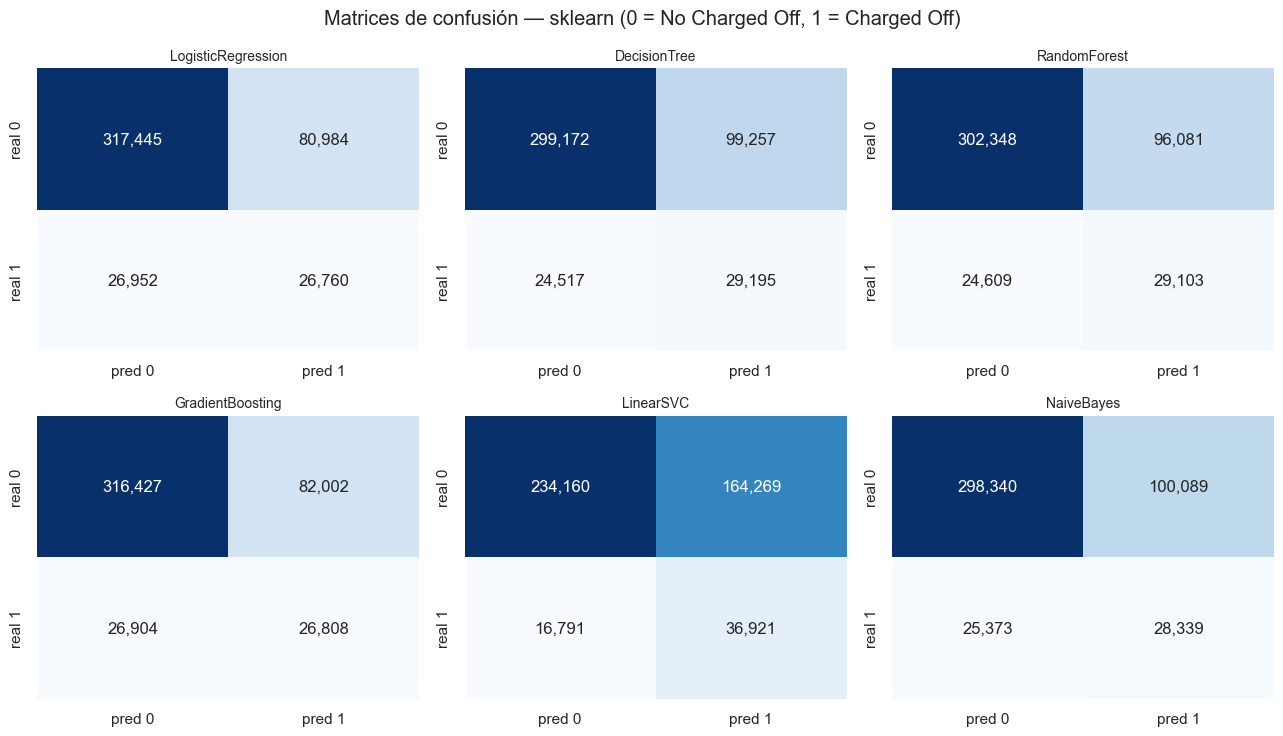

In [25]:
assert list(sklearn_results) == MODELOS, f"Faltan modelos sklearn: {set(MODELOS) - set(sklearn_results)}"
sklearn_metrics_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "matriz_confusion"}
                                   for k, v in sklearn_results.items()}).T
sklearn_metrics_df.index.name = "modelo"
display(sklearn_metrics_df)


def graficar_matrices_confusion(resultados, entorno):
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
    for ax, m in zip(axes.ravel(), MODELOS):
        cm = np.array(resultados[m]["matriz_confusion"])
        sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["pred 0", "pred 1"], yticklabels=["real 0", "real 1"])
        ax.set_title(m, fontsize=10)
    fig.suptitle(f"Matrices de confusión — {entorno} (0 = No Charged Off, 1 = Charged Off)")
    plt.tight_layout()
    guardar_figura(f"matrices_confusion_{entorno}")
    plt.show()


graficar_matrices_confusion(sklearn_results, "sklearn")

In [26]:
# Puntuaciones continuas de test con su id (insumo de DeLong, McNemar, bootstrap y ROC)
sklearn_scores_df = pd.DataFrame({"id": id_test, "default": y_test,
                                  **{f"score_{k}": v for k, v in sklearn_scores.items()}})
sklearn_scores_df.to_parquet(ARTIFACTS_DIR / "sklearn_scores_test.parquet", index=False)
sklearn_metrics_df.to_pickle(ARTIFACTS_DIR / "sklearn_metrics.pkl")
print(f"Puntuaciones guardadas en {ARTIFACTS_DIR / 'sklearn_scores_test.parquet'} "
      f"({len(sklearn_scores_df):,} filas, columnas: {list(sklearn_scores_df.columns)})")

Puntuaciones guardadas en artifacts_modelado\sklearn_scores_test.parquet (452,141 filas, columnas: ['id', 'default', 'score_LogisticRegression', 'score_DecisionTree', 'score_RandomForest', 'score_GradientBoosting', 'score_LinearSVC', 'score_NaiveBayes'])


**Interpretación (scikit-learn):** 

Los seis modelos discriminan de forma moderada y muy parecida (ROC-AUC entre 0.702 y 0.729). El mejor es el boosting con histogramas, HistGradientBoosting (0.7288, entrenado en 112 s). La regresión logística queda a solo 0.005 (0.7241, 86 s) y el RandomForest empata con ella (0.7238), pero tarda 11,255 s, el 95 % del tiempo de entrenamiento del entorno, sin aportar mejora. Que tres algoritmos tan distintos terminen casi empatados, y que ninguno supere 0.73, sugiere que el límite está en la información disponible al originar el préstamo y no en el algoritmo. La exactitud (0.60–0.76) no es informativa: predecir siempre «no incumple» ya da 0.881, y el umbral de cada modelo se eligió con train para maximizar el F1 de la clase minoritaria. Con la regresión logística se detecta el 49.8 % de los incumplimientos con una precisión de 0.248, unas 2.1 veces la tasa base (0.119), un beneficio real pero modesto. El AUC de test es mayor o igual que el de la validación cruzada en todos los modelos, así que no hay sobreajuste visible. Varios hiperparámetros óptimos cayeron en el borde de la malla (árboles de profundidad mínima, regularización más fuerte).